In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import svm
from sklearn import metrics

# Učitavanje skupa podataka

In [3]:
data = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')

# Pretprocesiranje podataka

In [4]:
data = data.drop(columns=['No'])
data = data.dropna(subset=['pm2.5'])
data = pd.get_dummies(data, columns=['cbwd'], dtype=int)

Ulazni atributi izdvajaju se u skup `x`, dok ciljnu promenljivu predstavlja koncentracija PM2.5 sadržana u atributu `pm2.5`.

In [5]:
x = data.drop(columns=['pm2.5'])
y = data['pm2.5']

In [6]:
x.shape

(41757, 14)

In [7]:
y.shape

(41757,)

In [8]:
feature_names = x.columns
number_of_features = len(feature_names)

## Podela podataka

Podaci se dele na trening, validacioni i test skup. Trening skup koristi se za obučavanje modela, validacioni skup za izbor hiperparametara, dok se test skup koristi za konačnu evaluaciju izabranog modela.

In [9]:
x_train_val, x_test, y_train_val, y_test = model_selection.train_test_split(x, y, test_size=0.33, random_state=7)

In [10]:
x_train, x_val, y_train, y_val = model_selection.train_test_split(x_train_val, y_train_val, train_size=0.8, random_state=7)

## Standardizacija podataka

SVM modeli su osetljivi na različite opsege vrednosti ulaznih atributa, zbog čega se vrši njihova standardizacija.

Parametri standardizacije određuju se isključivo na trening skupu, a zatim se isti parametri primenjuju na trening, validacioni i test skup. Na ovaj način se sprečava curenje informacija iz validacionog i test skupa.

In [11]:
scaler = preprocessing.StandardScaler()

In [12]:
scaler.fit(x_train)

StandardScaler()

In [13]:
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

# Linearni SVM 

Najpre se primenjuje linearni SVM regresioni model (`LinearSVR`). Ovaj model pretpostavlja približno linearnu vezu između ulaznih atributa i ciljne promenljive i predstavlja osnovu za poređenje sa nelinearnim SVM modelom.

In [14]:
linear_svm = svm.LinearSVR( C=1, random_state=7, max_iter=10000)

In [15]:
linear_svm.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",7
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",10000
,"epsilon epsilon: float, default=0.0Epsilon parameter in the epsilon-insensitive loss function. Notethat the value of this parameter depends on the scale of the targetvariable y. If unsure, set ``epsilon=0``.",0.0
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.",1
,"loss loss: {'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='epsilon_insensitive'Specifies the loss function. The epsilon-insensitive loss(standard SVR) is the L1 loss, while the squared epsilon-insensitiveloss ('squared_epsilon_insensitive') is the L2 loss.",'epsilon_insensitive'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes `[x_1, ...,x_n, intercept_scaling]`, i.e. a ""synthetic"" feature with a constantvalue equal to `intercept_scaling` is appended to the instance vector.The intercept becomes intercept_scaling * synthetic feature weight.Note that liblinear internally penalizes the intercept, treating itlike any other term in the feature vector. To reduce the impact of theregularization on the intercept, the `intercept_scaling` parameter canbe set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1.0
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features` and `loss`. If`n_samples` < `n_features` and optimizer supports chosen `loss`,then dual will be set to True, otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
Name,Type,Value


In [16]:
y_val_pred_linear_svm = linear_svm.predict(x_val)

In [17]:
print('LinearSVR')

print('R2:', metrics.r2_score(y_val, y_val_pred_linear_svm))
print('MAE:', metrics.mean_absolute_error(y_val, y_val_pred_linear_svm))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_val, y_val_pred_linear_svm)))

LinearSVR
R2: 0.20220263771820424
MAE: 52.439074647753294
RMSE: 79.84116249212589


Linearni SVM model ostvaruje R² vrednost od približno 0,20 na validacionom skupu. Relativno niska vrednost R² ukazuje da linearni SVM ima ograničenu sposobnost da opiše odnos između meteoroloških atributa i koncentracije PM2.5.

Rezultat je u skladu sa prethodno dobijenim rezultatima linearne regresije i ukazuje na mogućnost postojanja izraženijih nelinearnih odnosa u podacima.

## Linearni SVM  sa podešavanjem hiperparametra

In [18]:
Cs_linear = [0.01, 0.1, 1, 10, 100]

best_r2_linear = -np.inf
best_C_linear  = None

In [19]:
for C in Cs_linear:
    linear_svm_C = svm.LinearSVR( C=C, random_state=7, max_iter=10000)
    linear_svm_C.fit(x_train, y_train)
    y_val_pred_C = linear_svm_C.predict(x_val)
    r2_score_linear = metrics.r2_score(y_val, y_val_pred_C)
        
    if r2_score_linear > best_r2_linear:
        best_C_linear = C
        best_r2_linear = r2_score_linear

In [20]:
print('Najbolji hiperparamtar C = {} i R2 = {}'.format( best_C_linear, best_r2_linear))

Najbolji hiperparamtar C = 100 i R2 = 0.2060005240531253


In [50]:
best_linear = svm.LinearSVR( C=best_C_linear, random_state=7, max_iter=10000)

In [51]:
best_linear.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",7
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",10000
,"epsilon epsilon: float, default=0.0Epsilon parameter in the epsilon-insensitive loss function. Notethat the value of this parameter depends on the scale of the targetvariable y. If unsure, set ``epsilon=0``.",0.0
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"loss loss: {'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='epsilon_insensitive'Specifies the loss function. The epsilon-insensitive loss(standard SVR) is the L1 loss, while the squared epsilon-insensitiveloss ('squared_epsilon_insensitive') is the L2 loss.",'epsilon_insensitive'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes `[x_1, ...,x_n, intercept_scaling]`, i.e. a ""synthetic"" feature with a constantvalue equal to `intercept_scaling` is appended to the instance vector.The intercept becomes intercept_scaling * synthetic feature weight.Note that liblinear internally penalizes the intercept, treating itlike any other term in the feature vector. To reduce the impact of theregularization on the intercept, the `intercept_scaling` parameter canbe set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1.0
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features` and `loss`. If`n_samples` < `n_features` and optimizer supports chosen `loss`,then dual will be set to True, otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
Name,Type,Value


In [52]:
y_test_pred_linear = best_linear.predict(x_test)

print('Linear SVM - TEST')

print('R2:', metrics.r2_score(y_test, y_test_pred_linear))
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred_linear))
print( 'RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_linear)))

Linear SVM - TEST
R2: 0.19366168393682714
MAE: 54.35658525663164
RMSE: 83.8635183517107


# SVM sa RBF kernelom

Kako linearni model nije ostvario visoku tačnost, primenjuje se SVM regresioni model sa RBF kernelom. RBF kernel omogućava modelu da opisuje složenije i nelinearne odnose između ulaznih atributa i ciljne promenljive.

In [21]:
rbf_svm = svm.SVR( kernel='rbf', C=1, gamma='scale')

In [22]:
rbf_svm.fit(x_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [23]:
y_val_pred_rbf_svm = rbf_svm.predict(x_val)

In [24]:
print('SVR - RBF')
print('R2:', metrics.r2_score(y_val, y_val_pred_rbf_svm))
print('MAE:', metrics.mean_absolute_error(y_val, y_val_pred_rbf_svm))
print( 'RMSE:', np.sqrt(metrics.mean_squared_error(y_val, y_val_pred_rbf_svm)))

SVR - RBF
R2: 0.21907889369000932
MAE: 49.914690879862114
RMSE: 78.99218628580927


Početni SVM model sa RBF kernelom ostvaruje R² vrednost od približno 0,22 na validacionom skupu. Rezultat je nešto bolji od linearnog SVM modela, ali i dalje pokazuje da podrazumevane vrednosti hiperparametara nisu optimalne.

Zbog toga se u narednom koraku vrši podešavanje hiperparametara `C` i `gamma`.

## Podešavanje hiperparametara

Performanse SVM modela sa RBF kernelom u velikoj meri zavise od vrednosti hiperparametara `C` i `gamma`.

Parametar `C` određuje stepen kažnjavanja grešaka modela, dok `gamma` određuje uticaj pojedinačnih trening instanci pri formiranju nelinearne funkcije. Isprobavaju se različite kombinacije ovih parametara, a najbolja kombinacija bira se na osnovu R² vrednosti na validacionom skupu.

In [25]:
Cs = [0.1, 1, 10, 100]
gammas = [0.001, 0.01, 0.1, 1]

scores = np.zeros((len(Cs), len(gammas))) 

best_C = None
best_gamma = None
best_r2_score = -np.inf

In [26]:
for i, C in enumerate(Cs):
    for j, gamma in enumerate(gammas):
        model = svm.SVR(kernel='rbf', C=C, gamma=gamma)
        model.fit(x_train, y_train)
        y_val_pred = model.predict(x_val)
        r2 = metrics.r2_score(y_val, y_val_pred)
        
        scores[i, j] = r2 
        
        if r2 > best_r2_score:
            best_C = C
            best_gamma = gamma
            best_r2_score = r2

## Grafički prikaz R² score-a za različite vrednosti C i gamma

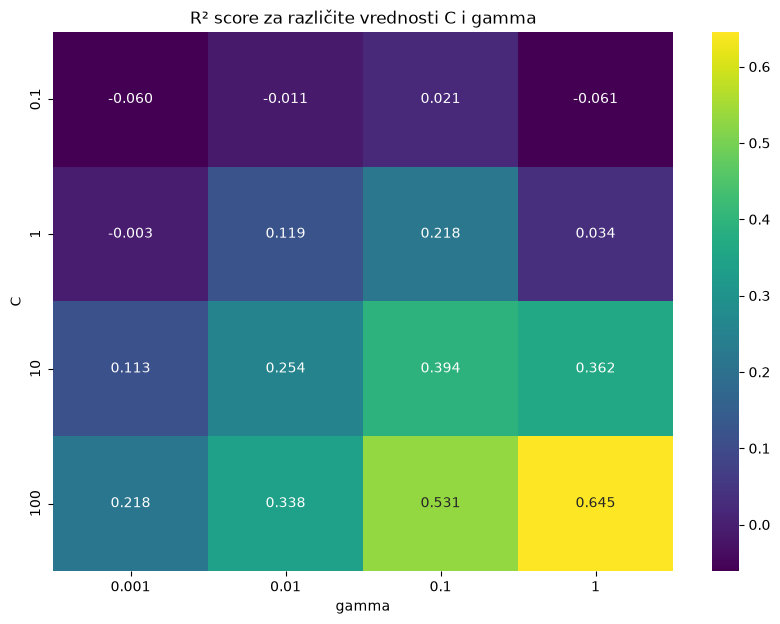

In [27]:
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(scores, annot=True, fmt='.3f', xticklabels=gammas, yticklabels=Cs, cmap='viridis')
plt.xlabel('gamma')
plt.ylabel('C')
plt.title('R² score za različite vrednosti C i gamma')
plt.show()

Heat mapa pokazuje da R² raste kako rastu vrednosti oba hiperparametra, odnosno sa porastom C i porastom gamma performanse modela se poboljšavaju, dok su za male vrednosti oba parametra rezultati blizu nule ili negativni.

In [56]:
print('Najbolji validation R2:', best_r2_score)

Najbolji validation R2: 0.6454116633706308


Najbolji rezultat na validacionom skupu ostvaren je za vrednosti `C = 100` i `gamma = 1`, pri čemu R² iznosi približno 0,645.

U odnosu na početni RBF model i linearni SVM, podešavanje hiperparametara dovelo je do značajnog poboljšanja performansi.

In [29]:
best_svm_model = svm.SVR(kernel='rbf', C=best_C, gamma=best_gamma)

In [30]:
best_svm_model.fit(x_train, y_train)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## Evaluacija najboljeg SVM modela

Nakon izbora najboljih hiperparametara, performanse izabranog SVM modela proveravaju se na test skupu koji nije korišćen tokom izbora parametara.

In [32]:
y_test_pred_svm = best_svm_model.predict(x_test)

In [33]:
print('RBF SVR - TEST')

print('R2:', metrics.r2_score(y_test, y_test_pred_svm))
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred_svm))
print( 'RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_svm)))

RBF SVR - TEST
R2: 0.6523868892747569
MAE: 32.51873731159663
RMSE: 55.063334026406714


Najbolji SVM model sa RBF kernelom na test skupu ostvaruje R² vrednost od približno 0,652, MAE od 32,52 i RMSE od 55,06.

Model objašnjava približno 65% varijabilnosti ciljne promenljive, što predstavlja značajno poboljšanje u odnosu na linearne modele. Slične R² vrednosti na validacionom i test skupu takođe ukazuju da model zadržava dobre performanse na podacima koje nije koristio tokom treniranja.

In [34]:
y_test_pred_linear_svm = linear_svm.predict(x_test)

In [35]:
linear_r2 = metrics.r2_score(y_test, y_test_pred_linear_svm)

In [36]:
rbf_r2 = metrics.r2_score(y_test, y_test_pred_svm)

In [37]:
print('LinearSVR R2:', linear_r2)
print('RBF SVR R2:', rbf_r2)

LinearSVR R2: 0.18957512708230972
RBF SVR R2: 0.6523868892747569


Linearni SVM model na test skupu ostvaruje R² vrednost od približno 0,19, što je znatno lošiji rezultat od SVM modela sa RBF kernelom.

Ovakva razlika dodatno ukazuje da odnos između ulaznih atributa i koncentracije PM2.5 nije dovoljno dobro opisan linearnom funkcijom i da primena nelinearnog kernela značajno poboljšava predviđanje.

## Grafički prikaz poređenja modela

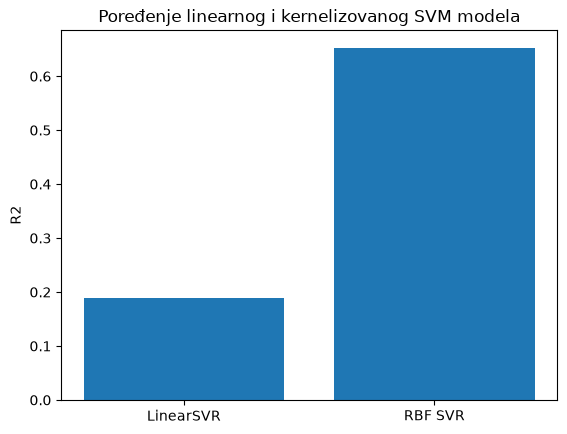

In [38]:
models = ['LinearSVR', 'RBF SVR']
scores = [linear_r2, rbf_r2]

plt.bar(models, scores)
plt.ylabel('R2')
plt.title('Poređenje linearnog i kernelizovanog SVM modela')
plt.show()

## Evaluacija najboljeg svm modela na uniji i trening i validacionog skupa

In [39]:
x_train_val_scaled = np.vstack([x_train, x_val])
y_train_val        = pd.concat([y_train, y_val])

In [40]:
x_train_val_scaled.shape

(27977, 14)

In [41]:
y_train_val.shape

(27977,)

In [42]:
best_svm_model_train_val = svm.SVR(kernel='rbf', C=best_C, gamma=best_gamma)
best_svm_model_train_val.fit(x_train_val_scaled, y_train_val)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [44]:
y_test_pred_svm_train_val = best_svm_model_train_val.predict(x_test)

In [45]:
print('RBF SVR - TEST - Unija Trening i Validacija')

print('R2:', metrics.r2_score(y_test, y_test_pred_svm_train_val))
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred_svm_train_val))
print( 'RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_svm_train_val)))

RBF SVR - TEST - Unija Trening i Validacija
R2: 0.6825464628722835
MAE: 30.66702383259387
RMSE: 52.62044482727252


In [46]:
rbf_union_r2 = metrics.r2_score(y_test, y_test_pred_svm_train_val)
print('RBF SVR UNION R2:', rbf_union_r2)

RBF SVR UNION R2: 0.6825464628722835


Uključivanjem validacionog skupa u trening R² vrednost dodatno raste sa približno 0.65 na 0.68, što pokazuje da model postiže bolju generalizaciju kada mu je na raspolaganju veća količina podataka za učenje.

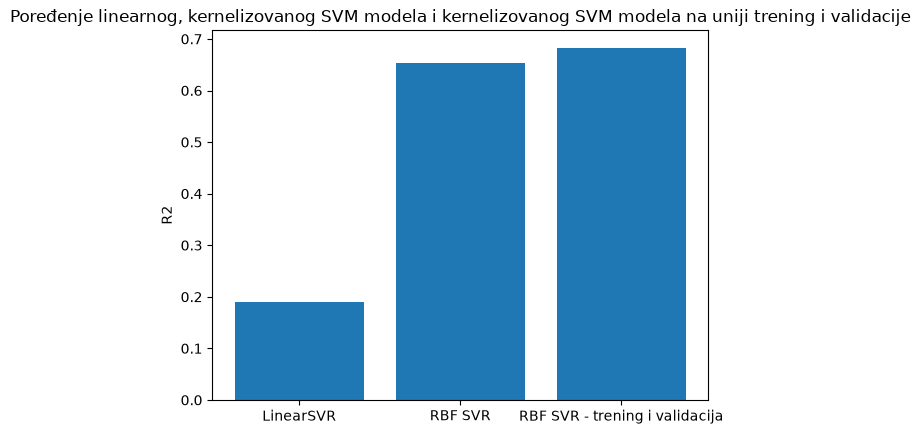

In [47]:
models = ['LinearSVR', 'RBF SVR', 'RBF SVR - trening i validacija']
scores = [linear_r2, rbf_r2, rbf_union_r2]

plt.bar(models, scores)
plt.ylabel('R2')
plt.title('Poređenje linearnog, kernelizovanog SVM modela i kernelizovanog SVM modela na uniji trening i validacije')
plt.show()

# Čuvanje modela i scaler-a

In [48]:
import joblib

In [53]:
joblib.dump(best_linear, "../models/03_LinearSVM.pkl")
joblib.dump(best_svm_model, "../models/03_SVM.pkl")
joblib.dump(best_svm_model_train_val, "../models/03_SVM_TrainVal.pkl")
joblib.dump(scaler, "../models/03_scaler.pkl")

['../models/03_scaler.pkl']